# 한국어 번역기

In [2]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.2.2
2.10.0+cu128
3.10.0


In [3]:
pip install tensorflow

In [4]:

!pip install sentencepiece

In [5]:
!pip install konlpy
!pip install mecab-python3

In [6]:
import os
import re
import urllib.request
import tarfile
import sentencepiece as spm
import pandas as pd
import numpy as np
import tensorflow as tf
from konlpy.tag import Mecab
from tqdm import tqdm


In [ ]:
# 1. 경로 설정
dataset_dir = os.path.expanduser("~/work/AIFFEL_quest_eng/NLP/NLP01/datasets")
os.makedirs(dataset_dir, exist_ok=True)
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")


In [8]:
# 기존에 잘못된 파일이 있다면 삭제 (다시 받기 위해)
if os.path.exists(tar_path):
    os.remove(tar_path)
    print("기존의 잘못된 파일을 삭제했습니다.")

url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 다시 다운로드
print("데이터 다운로드 중... ")
urllib.request.urlretrieve(url, tar_path)
print("다운로드 완료!")

기존의 잘못된 파일을 삭제했습니다.
데이터 다운로드 중... 
다운로드 완료!


In [9]:
data_folder = os.path.join(dataset_dir, "kor-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    # .tar.gz를 r(읽기)모드인데 gz(압축)된 상태로 열기
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "kor.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

압축 해제 중...


/tmp/ipykernel_4482/3330861497.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(dataset_dir)


압축 해제 완료!
데이터셋 디렉토리: ['korean-english-park.train.ko', 'korean-english-park.train.tar.gz', 'korean-english-park.train.en']


In [10]:
ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_path = os.path.join(dataset_dir, "korean-english-park.train.en")

In [11]:
# 각각의 파일에서 가져오기
with open(ko_path, "r", encoding="utf-8") as f:
    ko_lines = f.readlines()

with open(en_path, "r", encoding="utf-8") as f:
    en_lines = f.readlines()

# 표로 합치기
# strip()을 써서 문장 끝에 붙은 불필요한 줄바꿈(\n)을 지워주기
df = pd.DataFrame({
    "kor": [line.strip() for line in ko_lines],
    "eng": [line.strip() for line in en_lines]
})


print(f"전체 데이터 개수: {len(df)}")
df.head()

전체 데이터 개수: 94123


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


#### 데이터 정제

In [38]:
# 코랩용 Mecab 설치 스크립트 실행
!git clone https://github.com/somacnyel/mecab-ko-dic.git
!cd mecab-ko-dic && ./autogen.sh && make && sudo make install

# 파이썬 라이브러리 재설치 및 업데이트
!pip install konlpy
!pip install mecab-python3

# 설치 확인 테스트
from konlpy.tag import Mecab

Cloning into 'mecab-ko-dic'...
fatal: could not read Username for 'https://github.com': No such device or address
/bin/bash: line 1: cd: mecab-ko-dic: No such file or directory
아직 설정이 더 필요해요: The MeCab dictionary does not exist at "/usr/local/lib/mecab/dic/mecab-ko-dic". Is the dictionary correctly installed?
You can also try entering the dictionary path when initializing the Mecab class: "Mecab('/some/dic/path')"


In [39]:

from konlpy.tag import Mecab
import re

In [35]:
# 중복 제거 (set을 이용해 병렬 쌍 유지)
raw_pairs = list(zip(df['kor'], df['eng']))
cleaned_corpus = list(set(raw_pairs))
print(f"중복 제거 후 데이터 수: {len(cleaned_corpus)}")

중복 제거 후 데이터 수: 29928


In [47]:
def preprocess_korean(sentence):
    # 한글, 영문, 기본 구두점만 남기고 다 지우기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z?.!,]+", " ", sentence)
    return sentence.strip()

def preprocess_english(sentence):
    # 소문자로 바꾸고 영문, 기본 구두점만 남기기
    sentence = sentence.lower()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()
    # 타겟 언어(영어)에 <start>와 <end> 토큰 추가
    return f"<start> {sentence} <end>"

kor_corpus = []
eng_corpus = []
mecab = Mecab()

for kor, eng in cleaned_corpus:
    # 한글은 Mecab으로 토큰화 (형태소 분석)
    pre_kor = mecab.morphs(preprocess_korean(kor))
    # 영어는 split()으로 토큰화
    pre_eng = preprocess_english(eng).split()

    # 토큰 길이가 40 이하인 것만 선별
    if len(pre_kor) <= 40 and len(pre_eng) <= 40:
        # Tokenizer에 넣기 위해 다시 띄어쓰기로 연결해둠
        kor_corpus.append(" ".join(pre_kor))
        eng_corpus.append(" ".join(pre_eng))

print(f"필터링 후 최종 데이터 수: {len(kor_corpus)}")

필터링 후 최종 데이터 수: 23626


In [14]:
df = df[:30000]
df["eng"] = df["eng"].apply(lambda x: preprocess_sentence(x, is_korean=False))
df["kor"] = df["kor"].apply(lambda x: preprocess_sentence(x, is_korean=True))

df.head()

,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


In [30]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, kor_corpus.txt")

파일 저장 완료: eng_corpus.txt, kor_corpus.txt


In [26]:
kor_sample = df["kor"][10000]
eng_sample = df["eng"][10000]

print(kor_sample)
print(eng_sample)

그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다 .
clinton has vowed to stay in the race until someone gets enough delegates to clinch the nomination .


#### 데이터 토큰화

In [48]:
def tokenize(corpus, vocab_size=10000):
    # 이미 split과 mecab으로 띄어쓰기가 되어있으므로 filters=''로 설정
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=vocab_size, filters=''
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    # 문장 길이 맞추기 (빈 칸은 0으로 채움)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, tokenizer

VOCAB_SIZE = 10000
kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE)

print("토큰화 완료.", kor_tensor.shape)

토큰화 완료. (23626, 40)


#### 모델 설계

In [59]:
import torch.nn as nn
# 어떤 단어에 집중할지 점수 매기는 클래스
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # 번역하려는 단어랑 원문 단어랑 비교해서 점수내기
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # 에너지 점수 계산하고 소프트맥스로 단어 집중도 알려주기
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)

        return nn.functional.softmax(attention, dim=1)

In [60]:
# 한국어 읽고 의미 압축하는 인코더
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim) #단어를 좌표로 바꾸기
        self.rnn = nn.GRU(emb_dim, hidden_dim) #문장 흐름 기억하기

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)

        return outputs, hidden

In [61]:
# 인코더 보고 영어를 한 단어씩 뱉는 디코더
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim) #다음 단어 예측하기

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        # attention으로 원문 어디를 볼지 결정하기 decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 의미 context vector를 결합하여 예측값(영어단어) 생성
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

In [62]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None: # 학습할 때 trg 정답지 보면서 공부
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else: #테스트할때 정답 없이 때문에 sos_token을 생성
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1) #가장 확률 높은 단어 선택
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all(): #마침표 나오면 끝
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Keras Tokenizer를 사용 중이므로 word_index의 길이를 잽니다.
input_dim = len(kor_tokenizer.word_index) + 1  # 한국어 단어 수 (+1은 패딩용)
output_dim = len(eng_tokenizer.word_index) + 1 # 영어 단어 수
emb_dim = 256
hid_dim = 512

In [66]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [67]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(24728, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(25864, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=25864, bias=True)
  )
)


#### 훈련하기

In [73]:
from torch.utils.data import DataLoader

dataset = torch.utils.data.TensorDataset(
    torch.LongTensor(kor_tensor),
    torch.LongTensor(eng_tensor)
)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [69]:
import torch.nn as nn
import torch.optim as optim
pad_id = 0

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


In [75]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환. 모양 맞추기
        src = src.permute(1, 0).to(device)
        trg = trg.permute(1, 0).to(device)

        # 입력용과 정답용 쪼개기
        # trg_input: 마지막 단어(<end>)를 빼고 모델에게 힌트로 줍니다.
        trg_input = trg[:-1, :]
        # trg_label: 첫 단어(<start>)를 빼고 모델이 맞춰야 할 정답으로 씁니다.
        trg_label = trg[1:, :]

        # 이전 기울기 지우기
        optimizer.zero_grad()
        # 문제 풀기. 한국어 src보고 영어 trg_input 예측하기
        outputs,_ = model(src, trg_input)

        # 채점할 수 있게 결과를 한 줄로 길게 펴주기 (문장길이 * 배치 사이즈, 단어종류수)형태
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


In [71]:
from tqdm.notebook import tqdm

In [76]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 1/10, Train Loss: 5.6520


Epoch 2:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 2/10, Train Loss: 4.4968


Epoch 3:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 8/10, Train Loss: 1.1493


Epoch 9:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 9/10, Train Loss: 0.8877


Epoch 10:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 10/10, Train Loss: 0.6775
CPU times: user 18min 19s, sys: 2min 13s, total: 20min 32s
Wall time: 20min 45s


In [83]:

def evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=30):
    model.eval()

    # 한글 입력 문장 쪼개기
    sentence_pre = preprocess_korean(sentence)
    tokens = mecab.morphs(sentence_pre)

    # Keras Tokenizer로 단어를 숫자(ID)로 변환
    src_indexes = kor_tokenizer.texts_to_sequences([" ".join(tokens)])[0]

    # 모델에 넣기 위해 텐서로 바꾸고 세로로 세우기 (문장길이, 1)
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)

    # 단어장의  <start>와 <end> 번호 찾기
    bos_id = eng_tokenizer.word_index['<start>']
    eos_id = eng_tokenizer.word_index['<end>']

    with torch.no_grad():
        outputs, attentions = model(src_tensor, trg=None, max_len=max_len, bos_id=bos_id, eos_id=eos_id)

    # 가장 높은 확률 단어만 뽑기
    top1 = outputs.argmax(2).squeeze(1)

    # 번호를 다시 영어로 번역
    result = []
    for token in top1:
        word = eng_tokenizer.index_word.get(token.item(), '')
        if token.item() == eos_id: # <end>가 나오면 멈춤!
            break
        if word != '<start>' and word != '':
            result.append(word)

    return ' '.join(result), sentence_pre, attentions.squeeze(1).cpu().numpy()



In [85]:
def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=30):
    result, original, attention = evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len)
    print(sentence, result)

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in test_sentences:
    translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=30)

오바마는 대통령이다. obama is getting begin , he is just .
시민들은 도시 속에 산다. citizens of the kids found in cities around the city is on the .
커피는 필요 없다. it is unclear how it doesn t have a good conversation to .
일곱 명의 사망자가 발생했다. the three people dead were killed in an accident at the high profile .


In [92]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


Input: 오바마는 대통령이다.
Predicted: the president is .


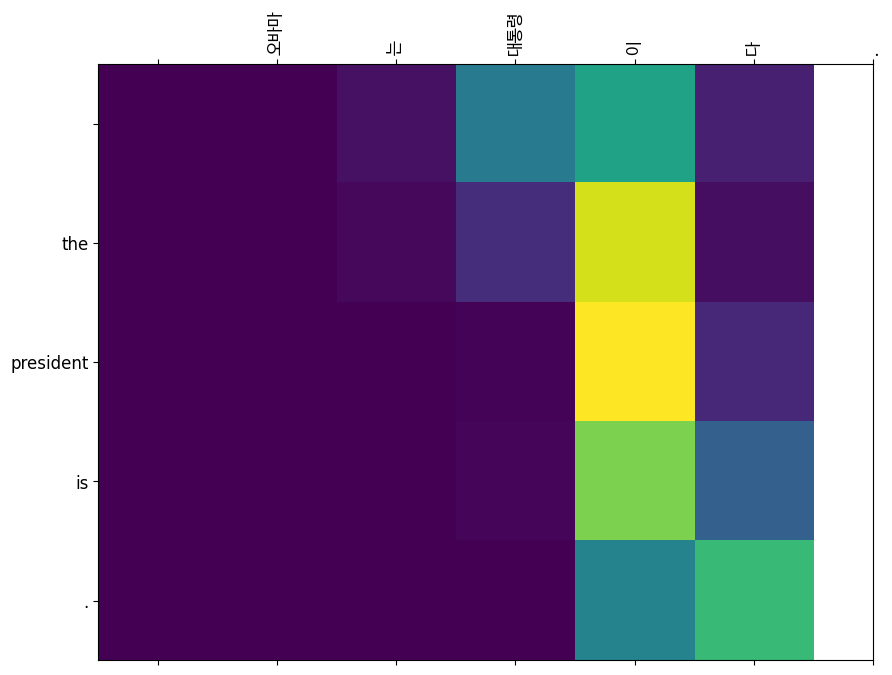

In [99]:
#  한글 폰트 설정 수정
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False

def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)

    # 어텐션 값을 색깔로 표시
    ax.matshow(attention, cmap='viridis')

    # x축: 한국어, y축: 영어
    # set_ticks를 먼저 호출하여 UserWarning 방지
    ax.set_xticks(range(len([''] + sentence)))
    ax.set_yticks(range(len([''] + predicted_sentence)))

    ax.set_xticklabels([''] + sentence, fontproperties=fontprop, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontsize=12)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

# 실제 예문으로 확인해보기
test_sentence = "오바마는 대통령이다."
result, original, attention = evaluate(test_sentence, model, kor_tokenizer, eng_tokenizer)

print(f'Input: {test_sentence}')
print(f'Predicted: {result}')

# 시각화 함수 호출
plot_attention(attention, mecab.morphs(preprocess_korean(test_sentence)), result.split())

임베딩 사이즈랑 히든 사이즈 조정해보기.
256에서 500로
512에서 1000로

학습도 10에서 20으로 늘려보자.

In [96]:
emb_dim = 500
hid_dim = 1000

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)

model = Seq2SeqAttention(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


In [100]:
def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=30):

    result, original, attention = evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len)

    print(f'Input: {sentence}')
    print(f'Predicted: {result}')

    # 문자열을 다시 리스트로 쪼개서 plot_attention에 단어 넣을 수 있음
    result_list = result.split()
    ko_tokens = mecab.morphs(preprocess_korean(sentence))

    # 쪼개진 단어를 시각화 함수로
    plot_attention(attention, ko_tokens, result_list)

Epoch 1:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 1/20, Train Loss: 0.1054


Epoch 2:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 2/20, Train Loss: 0.2697


Epoch 3:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 3/20, Train Loss: 0.4033


Epoch 4:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 4/20, Train Loss: 0.2830


Epoch 5:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 5/20, Train Loss: 0.1711

 Epoch 5 
Input: 오바마는 대통령이다.
Predicted: it is a .


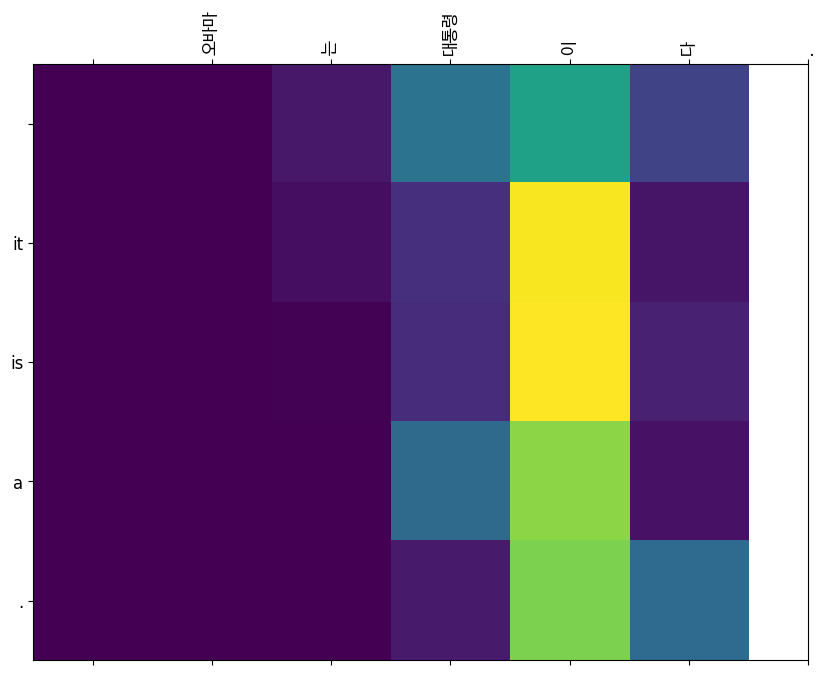

Epoch 6:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 6/20, Train Loss: 0.0949


Epoch 7:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 7/20, Train Loss: 0.0560


Epoch 8:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 8/20, Train Loss: 0.0372


Epoch 9:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 9/20, Train Loss: 0.0310


Epoch 10:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 10/20, Train Loss: 0.0350

 Epoch 10 
Input: 오바마는 대통령이다.
Predicted: he is south president obama s president , obama said .


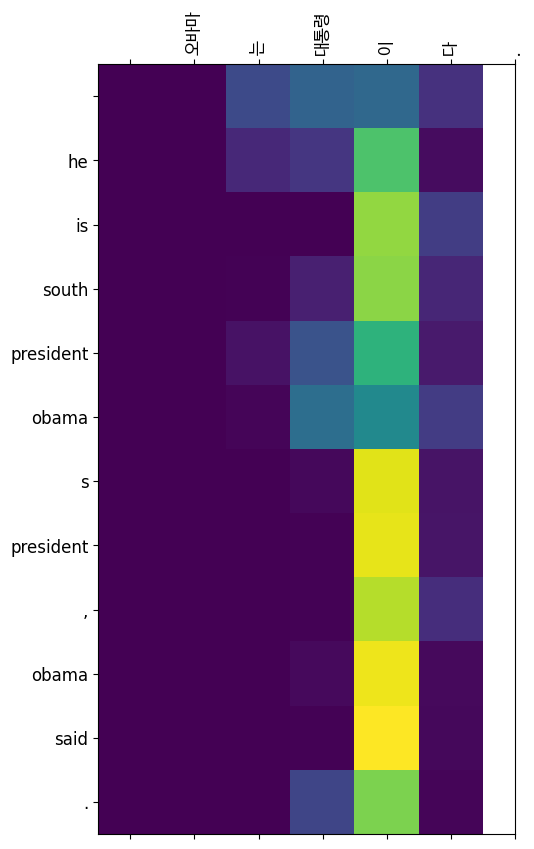

Epoch 11:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 11/20, Train Loss: 0.1063


Epoch 12:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 12/20, Train Loss: 0.3910


Epoch 13:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 13/20, Train Loss: 0.3355


Epoch 14:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 14/20, Train Loss: 0.2550


Epoch 15:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 15/20, Train Loss: 0.1918

 Epoch 15 
Input: 오바마는 대통령이다.
Predicted: i am . i was . president obama , the president of illinois .


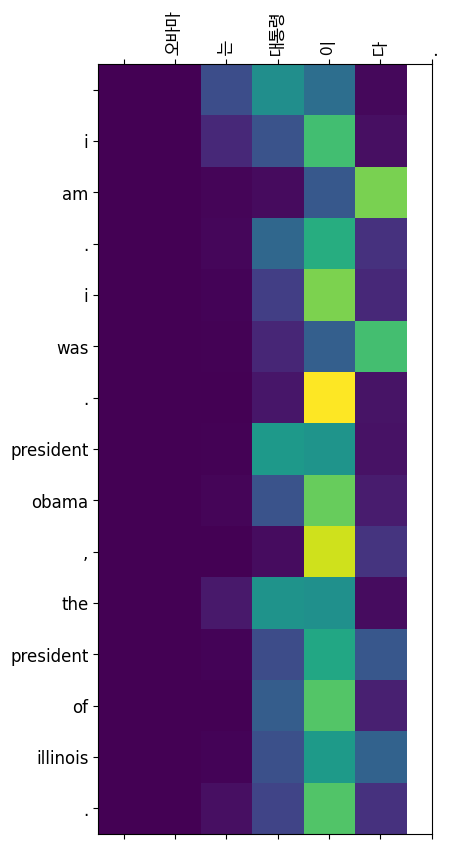

Epoch 16:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 16/20, Train Loss: 0.1525


Epoch 17:   0%|          | 0/370 [00:00<?, ?it/s]

In [ ]:
%%time


EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

    # 5번마다 번역 달라지는 내용 확인하기
    if (epoch + 1) % 5 == 0:
        print(f"\n Epoch {epoch+1} ")
        translate("오바마는 대통령이다.", model, kor_tokenizer, eng_tokenizer, max_len=30)